### Build a basic Chatbot with Langgraph (GRAPH API Functionality) 
Important components of langgraph

1.Edge-
2.Nodes
3.State




Graph Api-more easy and best
example of workflow

input -> start ->transcript->output --- get a transcript -> title generator -> content generator---> output


Transcript ->LLM + Prompt -> output

-> edge 
and input etc is node
every node has node implemenation ,perform some node functionality
like take the transcript and generate title


Where does state come in exisance?
State has some variables like transcript variable as soon as i execurte the first node and it will also be used in the 3rd node
--saving the values in states so that the entire graph can use the values
memory can also be used here


Functional Api-



Basic chatbot

start --> node(Chatbot) --> end

add external tools ,integrate,react agents


In [1]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages

### if i want to create the chatbot what kind of variables need to be saved in state?execute tthe grph as many number of times ,every conversation saved inside state,keep a variable to add all tha messages,appending the conversations.thats why state graph
### for this use reducers ,add(APPENDS) the messages instead of replacing

In [2]:
class State(TypedDict):
    # Messages have the type list The add_messaages fucntion
    #iN The annotation defines how this state key should be updated
    #(in this case,it appends messages to the list,rather then overwriting it)
    messages: Annotated[list, add_messages]


graph_builder = StateGraph(State)

In [3]:
graph_builder

In [4]:
import os 
from dotenv import load_dotenv

# Load environment variables from .env in project root
load_dotenv()

True

In [5]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model


llm=ChatGroq(model="llama3-8b-8192")

In [6]:
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.11'}}, output_version=None, profile={'name': 'Llama 3 8B', 'status': 'deprecated', 'release_date': '2024-04-18', 'last_updated': '2024-04-18', 'open_weights': True, 'max_input_tokens': 8192, 'max_output_tokens': 8192, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x0000017FB7CB2270>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000017FB7CB2CF0>, model_name='llama3-8b-8192', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [7]:
llm=ChatGroq(model="llama-3.3-70b-versatile")
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.11'}}, output_version=None, profile={'name': 'Llama 3.3 70B Versatile', 'release_date': '2024-12-06', 'last_updated': '2024-12-06', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 32768, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x0000017FB7D4E710>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000017FB7D4F110>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [8]:
#node definition
def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"][-1].content)]}

In [9]:
graph_builder = StateGraph(State)
#need to build the graph
graph_builder.add_node("llmchatbot",chatbot)
#add/create edges
graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot",END)

#compile the graph
graph=graph_builder.compile()

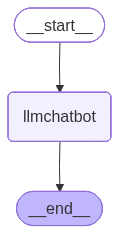

In [10]:
#visualize the graph
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass



In [11]:
from langchain_core.messages import HumanMessage

response=graph.invoke({"messages":"Hi"})

In [12]:
response["messages"][-1].content

"It's nice to meet you. Is there something I can help you with or would you like to chat?"

In [13]:
for event in graph.stream({"messages":"Hi How are you doing today?"}):
    for value in event.values():
        print(value["messages"][-1].content)

I'm doing well, thanks for asking. I'm a large language model, so I don't have emotions or feelings like humans do, but I'm always happy to chat and help with any questions or topics you'd like to discuss. How about you? How's your day going so far?


###  Integrate some external tools?

like provide me the receent AI News--- it cant do on its owns --> Need an external tool for it like Tavily:Web search

chatbot--> tool call-->TOOL NODE --> End 
i can also define some custom tools
How does the LLM know about tools
LLM is th brain for taking decisions llm IS BINDED with tools you have to provide doc string in  the tool 

Can make a tool call based on the specific input

### Chatbot with tools

start --> tool_calling llm -> tools(tavily search ,custom tools)tool node -> end


tool calling llm will decide that wheter it will give answer or make a tol call and tool will provide the output

In [14]:
from langchain_tavily import TavilySearch

tool=TavilySearch(max_results=2)
tool.invoke("What is langgraph?")

ModuleNotFoundError: No module named 'langchain_tavily'